## Initialize

### Import

In [1]:
# data and visualization
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# machine learning
from sklearn.metrics import accuracy_score, f1_score, classification_report, make_scorer, roc_auc_score
from sklearn.model_selection import cross_validate, KFold
from xgboost import XGBClassifier
import shap


# statistics
import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import SET_USE_BIC_LLF
from statsmodels.stats.outliers_influence import variance_inflation_factor

SET_USE_BIC_LLF(True)

### Define Functions

In [2]:
def glm_cv(X_train, y_train, k_splits=5):
    kf = KFold(n_splits=k_splits, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in kf.split(X_train):
        X_tr = sm.add_constant(X_train.iloc[train_idx].astype(float))
        X_val = sm.add_constant(X_train.iloc[val_idx].astype(float))
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]
        
        glm = sm.GLM(y_tr, X_tr, family=sm.families.Binomial()).fit()
        y_pred = glm.predict(X_val)
        
        scores.append({
            'ACC': accuracy_score(y_val, (y_pred >= 0.5).astype(int)),
            'F1': f1_score(y_val, (y_pred >= 0.5).astype(int), average='macro'),
            'AUC': roc_auc_score(y_val, y_pred)
        })
    
    for k in scores[0].keys():
        vals = [s[k] for s in scores]
        print(f"CV {k}: {np.mean(vals):.3f} ± {np.std(vals):.3f}")

    pass

def stepwise_glm_backward(X, y, criterion="AIC", verbose=True):

    crit = criterion.upper()
    X_current = X.copy().astype(float)
    history = []
    iteration = 0

    while True:
        iteration += 1

        X_const = sm.add_constant(X_current)
        base_model = sm.GLM(y, X_const, family=sm.families.Binomial()).fit()

        base_score = base_model.aic if crit == "AIC" else base_model.bic
        base_rss = base_model.deviance

        # This is replica of MASS stepAIC verbose output
        if verbose:
            print(f"\nStep:  {crit}={base_score:.3f}")
            formula = "y ~ const + " + " + ".join(X_current.columns) if len(X_current.columns) > 0 else "y ~ 1"
            print(formula)
            print()
            
            # Header
            var_width = 75
            print("=" * 125)
            print(f"{'Variable':<{var_width}} {'Df':>8} {'Sum of Sq':>14} {'RSS':>14} {crit:>10}")
            print("-" * 125)

        best_score = base_score
        worst_feature = None
        best_model = base_model

        rows = []
        rows.append(("<none>", "", "", base_rss, base_score))

        for feature in X_current.columns:
            X_temp = X_current.drop(columns=[feature])
            X_temp_const = sm.add_constant(X_temp.astype(float))
            model_temp = sm.GLM(y, X_temp_const, family=sm.families.Binomial()).fit()

            rss = model_temp.deviance
            sumsq = rss - base_rss
            score = model_temp.aic if crit == "AIC" else model_temp.bic

            rows.append((f"- {feature}", 1, sumsq, rss, score))

            if score < best_score:
                best_score = score
                worst_feature = feature
                best_model = model_temp

        # Sort by AIC/BIC (ascending)
        rows_sorted = sorted(rows, key=lambda x: x[4])

        # This is replica of MASS stepAIC verbose output
        if verbose:
            var_width = 75
            for row in rows_sorted:
                var, df, sumsq, rss, sc = row
                if var == "<none>":
                    print(f"{var:<{var_width}} {'-':>8} {'-':>14} {rss:>14.3f} {sc:>10.3f}")
                else:
                    print(f"{var:<{var_width}} {df:>8} {sumsq:>14.3f} {rss:>14.3f} {sc:>10.3f}")
            print("=" * 125)

        if worst_feature is None:
            if verbose:
                print("\n>>> No improvement — stopping")
            break

        if verbose:
            print(f"\n>>> Removed: {worst_feature}  (New {crit}={best_score:.3f})")

        history.append({
            "Step": iteration,
            "Removed": worst_feature,
            crit: best_score
        })

        X_current = X_current.drop(columns=[worst_feature])

    return X_current, best_model, history




def stepwise_glm_forward(X, y, criterion="AIC", verbose=True):

    crit = criterion.upper()
    X_current = X.copy().astype(float)
    iteration = 0
    history = []

    # start with intercept-only model
    X_current = pd.DataFrame(index=X.index)

    base_const = sm.add_constant(X_current)
    base_model = sm.GLM(y, base_const, family=sm.families.Binomial()).fit()

    current_model = base_model
    current_rss = current_model.deviance
    current_aic = current_model.aic if crit == "AIC" else current_model.bic

    remaining = list(X.columns)
    iteration = 0

    while True:
        iteration += 1

        # This is replica of MASS stepAIC verbose output
        if verbose:
            print(f"\nStep:  {crit}={current_aic:.3f}")
            if len(X_current.columns) > 0:
                formula = "y ~ const + " + " + ".join(X_current.columns)
            else:
                formula = "y ~ 1 (intercept only)"
            print(formula)
            print()
            
            # Header
            var_width = 75
            print("=" * 125)
            print(f"{'Variable':<{var_width}} {'Df':>8} {'Sum of Sq':>14} {'RSS':>14} {crit:>10}")
            print("-" * 125)

        best_score = current_aic
        best_feature = None
        best_model_temp = current_model

        rows = []
        rows.append(("<none>", "", "", current_rss, current_aic))

        for feature in remaining:
            X_temp = pd.concat([X_current, X[[feature]]], axis=1)
            X_temp_const = sm.add_constant(X_temp.astype(float))
            model_temp = sm.GLM(y, X_temp_const, family=sm.families.Binomial()).fit()

            rss = model_temp.deviance
            sumsq = current_rss - rss  # positive = reduction in deviance (good)
            score = model_temp.aic if crit == "AIC" else model_temp.bic

            rows.append((f"+ {feature}", 1, sumsq, rss, score))

            if score < best_score:
                best_score = score
                best_feature = feature
                best_model_temp = model_temp

        # Sort by AIC/BIC (ascending) - best options first
        rows_sorted = sorted(rows, key=lambda x: x[4])

        # This is replica of MASS stepAIC verbose output
        if verbose:
            var_width = 75
            for row in rows_sorted:
                var, df, sumsq, rss, sc = row
                if var == "<none>":
                    print(f"{var:<{var_width}} {'-':>8} {'-':>14} {rss:>14.3f} {sc:>10.3f}")
                else:
                    print(f"{var:<{var_width}} {df:>8} {sumsq:>14.3f} {rss:>14.3f} {sc:>10.3f}")
            print("=" * 125)

        if best_feature is None:
            if verbose:
                print("\n>>> No improvement — stopping")
            break

        if verbose:
            print(f"\n>>> Added: {best_feature}  (New {crit}={best_score:.3f})")

        history.append({
            "Step": iteration,
            "Added": best_feature,
            crit: best_score
        })

        # update model
        X_current = pd.concat([X_current, X[[best_feature]]], axis=1)
        remaining.remove(best_feature)
        current_model = best_model_temp
        current_rss = current_model.deviance
        current_aic = best_score

        if len(remaining) == 0:
            if verbose:
                print("\n>>> No variables left — stopping")
            break

    return X_current, current_model, history

def evaluate_glm_model(X_train, X_test, y_train, y_test, compute_vif=False):
    """
    Fit GLM model and evaluate performance metrics.
    """
    X_train_const = sm.add_constant(X_train.astype(float))
    X_test_const  = sm.add_constant(X_test.astype(float))
    
    model = sm.GLM(
        y_train,
        X_train_const,
        family=sm.families.Binomial()
    ).fit()
    
    y_train_prob = model.predict(X_train_const)
    y_test_prob  = model.predict(X_test_const)
    y_train_pred = (y_train_prob >= 0.5).astype(int)
    y_test_pred  = (y_test_prob >= 0.5).astype(int)
    
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test  = accuracy_score(y_test, y_test_pred)
    f1_train  = f1_score(y_train, y_train_pred, average='macro')
    f1_test   = f1_score(y_test, y_test_pred, average='macro')
    auc_train = roc_auc_score(y_train, y_train_prob)
    auc_test  = roc_auc_score(y_test, y_test_prob)
    
    print(f"Train ACC: {acc_train:.3f}, F1: {f1_train:.3f}, AUC: {auc_train:.3f}")
    print(f"Test  ACC: {acc_test:.3f}, F1: {f1_test:.3f}, AUC: {auc_test:.3f}\n")
    glm_cv(X_train, y_train)
    
    print(f"AIC = {model.aic:.3f}, BIC = {model.bic:.3f}")
    
    if compute_vif:
        vif_values = [variance_inflation_factor(X_train.astype(float).values, i) for i in range(X_train.astype(float).shape[1])]
        max_vif = max(vif_values)
        print(f"Max VIF: {max_vif:.3f}")
    
    print(model.summary())
    
    return model


def backward_elimination_classification(X_train, y_train, p_threshold=0.05):
    """
    Backward elimination for classification (Binomial GLM).
    Removes highest p-value feature iteratively.
    """
    X_current = X_train.astype(float).copy()
    removed_features = []
    iteration = 0

    while True:
        iteration += 1

        X_const = sm.add_constant(X_current)

        model = sm.GLM(
            y_train,
            X_const,
            family=sm.families.Binomial()
        ).fit()

        pvalues = model.pvalues[1:]
        max_p = pvalues.max()
        worst_feat = pvalues.idxmax()

        y_pred_prob = model.predict(X_const)
        y_pred_class = (y_pred_prob >= 0.5).astype(int)

        acc = accuracy_score(y_train, y_pred_class)
        f1 = f1_score(y_train, y_pred_class, average='macro')
        auc = roc_auc_score(y_train, y_pred_prob)

        print("\n" + "="*80)
        print(f"Iteration {iteration}")
        print("="*80)
        print(f"Features remaining: {len(X_current.columns)}")
        print(f"Worst feature: {worst_feat}")
        print(f"Worst p-value: {max_p:.4f}")
        print(f"Train ACC: {acc:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")

        if max_p < p_threshold:
            print(f"\n All features significant (p < {p_threshold})")
            break

        print(f"Removing: {worst_feat}")
        removed_features.append((worst_feat, max_p))
        X_current = X_current.drop(columns=[worst_feat])

    print("\n" + "="*80)
    print("BACKWARD ELIMINATION COMPLETE")
    print("="*80)
    print(f"Features removed: {len(removed_features)}")
    print(f"Features remaining: {len(X_current.columns)}")
    print("\nRemoved features:")
    for feat, pval in removed_features:
        print(f"  - {feat} (p = {pval:.4f})")

    return X_current, model, removed_features

def lr_importance(X, y, features):
    full_model = sm.GLM(y, sm.add_constant(X), family=sm.families.Binomial()).fit()
    
    importance = {}
    for feat in features:
        X_reduced = X.drop(columns=[feat])
        reduced = sm.GLM(y, sm.add_constant(X_reduced), family=sm.families.Binomial()).fit()
        lr_stat = 2 * (full_model.llf - reduced.llf)  # chi-square statistic
        importance[feat] = lr_stat
    
    return pd.Series(importance).sort_values(ascending=False)

def evaluate_VIF_LRT(drop_list, X_train, X_test, y_train, y_test):
    X_subset = X_train.copy()

    # Exclude const from VIF calculation
    current_features = [f for f in X_subset.columns if f != 'const']

    # Drop features manually FIRST
    current_features = [f for f in current_features if f not in drop_list]
    X_current = X_train[current_features]

    # Calculate importances for current feature set
    importances = lr_importance(X_current, y_train, current_features)

    # Calculate VIF with importance AFTER dropping
    vif_df = pd.DataFrame({
        'feature': X_current.columns,
        'VIF': [variance_inflation_factor(X_current.values, i) for i in range(X_current.shape[1])],
        'importance': X_current.columns.map(importances)
    }).sort_values('VIF', ascending=False)
    print(vif_df.to_string())
    print(f"\nMax VIF: {vif_df['VIF'].max():.1f}\n")

    # Check correlation of highest VIF feature with all others
    highest_vif_feature = vif_df.iloc[0]['feature']
    print(f"\nCorrelations with {highest_vif_feature} (importance: {importances.get(highest_vif_feature, 'N/A'):.2f}.):\n")
    corr_with_highest = X_current.corrwith(X_current[highest_vif_feature]).abs().sort_values(ascending=False)
    
    # Create DataFrame with both correlation and importance
    corr_importance_df = pd.DataFrame({
        'Correlation': corr_with_highest,
        'VIF': vif_df.set_index('feature').loc[corr_with_highest.index, 'VIF'],
        'LRT': corr_with_highest.index.map(importances),
    })
    print(corr_importance_df.to_string())
    print()
    
    X_train_const = sm.add_constant(X_current.astype(float))
    X_test_const = sm.add_constant(X_test[X_current.columns].astype(float))
    glm = sm.GLM(y_train, X_train_const, family=sm.families.Binomial()).fit()
    
    y_train_prob = glm.predict(X_train_const)
    y_train_pred = (y_train_prob >= 0.5).astype(int)
    y_test_prob = glm.predict(X_test_const)
    y_test_pred = (y_test_prob >= 0.5).astype(int)
    
    print(f"Train Acc: {accuracy_score(y_train, y_train_pred):.3f}, AUC: {roc_auc_score(y_train, y_train_prob):.3f}, F1: {f1_score(y_train, y_train_pred, average='macro'):.3f}")
    print(f"Test  Acc: {accuracy_score(y_test, y_test_pred):.3f}, AUC: {roc_auc_score(y_test, y_test_prob):.3f}, F1: {f1_score(y_test, y_test_pred, average='macro'):.3f}")
    print("\n")
    print(glm.summary())

### Input Data

In [2]:
with open("PROCESSED/DATA/merged_and_dropped.cat_cols.json") as f:
    cat_cols = json.load(f)

X_train = pd.read_parquet("INPUTS/TRAIN/X_train.parquet")
X_test = pd.read_parquet("INPUTS/TEST/X_test.parquet")
y_train = pd.read_parquet("INPUTS/TRAIN/y_train.parquet")
y_test = pd.read_parquet("INPUTS/TEST/y_test.parquet")

# ordinal categorical columns
ordinal_cols = ['P_HUQ__HUQ010_General_health_condition', 'P_HUQ__HUQ051_times_receive_healthcare_over_past_year']

# drop ordinal from cat_cols
cat_cols = [c for c in cat_cols if c not in ordinal_cols]

X_train[cat_cols] = X_train[cat_cols].astype("category")
X_test[cat_cols] = X_test[cat_cols].astype("category")

num_cols = [c for c in X_train.columns if c not in cat_cols]

# one-hot encode categorical variables
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# ensure target is categorical
y_train_cat = y_train.iloc[:, 0].astype("category")
y_test_cat  = y_test.iloc[:, 0].astype("category")

## XGB

In [4]:
# best parameters
with open("RESULTS/BASELINES/PARAMETERS/XGBClassifier_BEST_HYPER.json") as f:
    xgb_param = json.load(f)

# model with best parameters
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    **xgb_param
)

# cross-validation
scoring = {'accuracy': 'accuracy',
           'f1': make_scorer(f1_score, average='macro'),
           'auc': 'roc_auc'}
cv_results = cross_validate(xgb, X_train_encoded, y_train_cat, cv=5, scoring=scoring)

# fit
xgb.fit(X_train_encoded, y_train_cat)

# evaluate
y_pred_train = xgb.predict(X_train_encoded)
y_pred_test  = xgb.predict(X_test_encoded)

acc_train = accuracy_score(y_train_cat, y_pred_train)
acc_test  = accuracy_score(y_test_cat, y_pred_test)

f1_train = f1_score(y_train_cat, y_pred_train, average='macro')
f1_test  = f1_score(y_test_cat, y_pred_test, average='macro')

auc_train = roc_auc_score(y_train_cat, xgb.predict_proba(X_train_encoded)[:, 1])
auc_test  = roc_auc_score(y_test_cat, xgb.predict_proba(X_test_encoded)[:, 1])

print(f"CV accuracy    : {cv_results['test_accuracy'].mean():.3f}, F1: {cv_results['test_f1'].mean():.3f}, AUC: {cv_results['test_auc'].mean():.3f}")
print(f"Train accuracy : {acc_train:.3f}, F1: {f1_train:.3f}, AUC: {auc_train:.3f}")
print(f"Test  accuracy : {acc_test:.3f}, F1: {f1_test:.3f}, AUC: {auc_test:.3f}")

print(f"CV Accuracy    : {cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}")
print(f"CV F1          : {cv_results['test_f1'].mean():.3f} ± {cv_results['test_f1'].std():.3f}")
print(f"CV AUC         : {cv_results['test_auc'].mean():.3f} ± {cv_results['test_auc'].std():.3f}")


print("\nClassification report:\n")
print(classification_report(y_test_cat, y_pred_test))

CV accuracy    : 0.877, F1: 0.752, AUC: 0.903
Train accuracy : 0.941, F1: 0.888, AUC: 0.977
Test  accuracy : 0.900, F1: 0.788, AUC: 0.922
CV Accuracy    : 0.877 ± 0.002
CV F1          : 0.752 ± 0.004
CV AUC         : 0.903 ± 0.007

Classification report:

              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      1642
         1.0       0.74      0.55      0.63       306

    accuracy                           0.90      1948
   macro avg       0.83      0.76      0.79      1948
weighted avg       0.89      0.90      0.89      1948



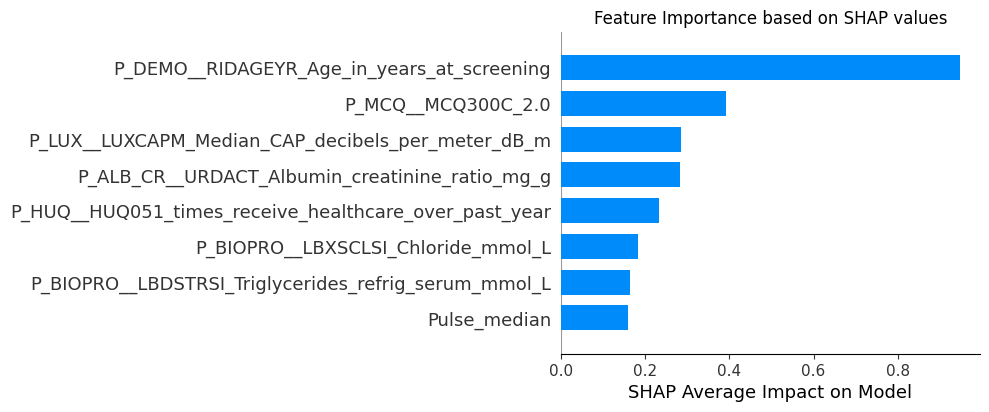

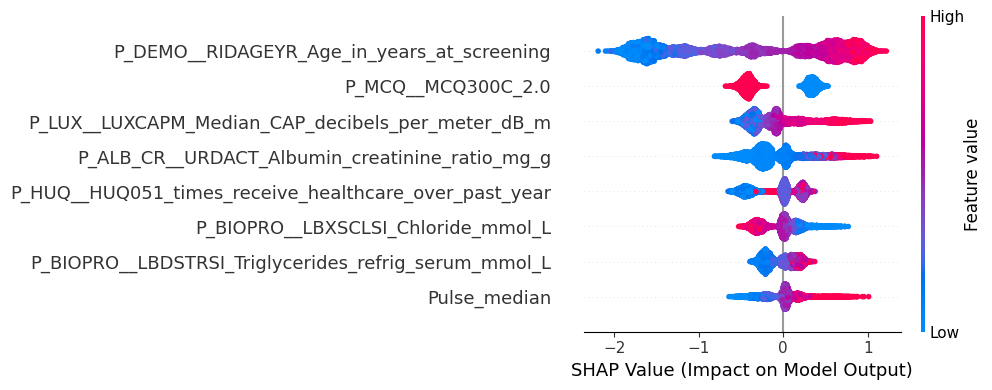

In [5]:
# 1. initialize explainer
explainer = shap.TreeExplainer(xgb)

# 2. compute SHAP values (main effects)
shap_values = explainer.shap_values(X_train_encoded)

feature_importance = np.abs(shap_values).mean(axis=0)
feature_names = X_train_encoded.columns

# global bar plot
shap.summary_plot(shap_values, X_train_encoded, plot_type="bar", max_display=8, plot_size=(10, 4), show=False)
plt.title("Feature Importance based on SHAP values")
plt.xlabel("SHAP Average Impact on Model")
plt.show()

# beeswarm plot
shap.summary_plot(shap_values, X_train_encoded, max_display=8, plot_size=(10, 4), show=False)
plt.xlabel("SHAP Value (Impact on Model Output)")
plt.show()

# Sort by importance
indices = np.argsort(feature_importance)[::-1][:15]

In [6]:
# # 3. (optional, can be slow) interaction values
# shap_interaction_values = explainer.shap_interaction_values(X_train_encoded)

# # 4. Compute mean absolute interaction values
# interaction_matrix = np.abs(shap_interaction_values).mean(axis=0)

# # 5. Turn into a ranked list of feature pairs
# top_idx = indices[:20] # top 20 features for interactions
# top_cols = X_train_encoded.columns[top_idx]
# pairs = []

# for i in range(len(top_cols)):
#     for j in range(i + 1, len(top_cols)):  # upper triangle only
#         pairs.append((top_cols[i], top_cols[j], interaction_matrix[top_idx[i], top_idx[j]]))

# interaction_df = pd.DataFrame(
#     pairs,
#     columns=["feature_1", "feature_2", "mean_abs_interaction"]
# ).sort_values("mean_abs_interaction", ascending=False)

# print(interaction_df)

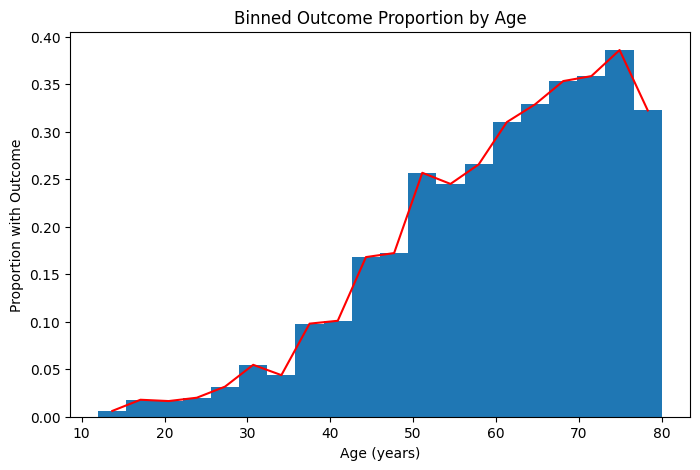

In [7]:
# Binned Proba for age
binned_var = 'P_DEMO__RIDAGEYR_Age_in_years_at_screening'
number_of_bins = 20
counts, bin_edges = np.histogram(X_train[binned_var], bins=number_of_bins)
bin_indices = np.digitize(X_train[binned_var], bins=bin_edges, right=True)

# Fix indices to be in range 0 to number_of_bins - 1
bin_indices = np.clip(bin_indices - 1, 0, number_of_bins - 1)

y_train_bin = y_train['IS_DIABETES']

bin_probas = []
for i in range(number_of_bins):
    bin_mask = (bin_indices == i)
    if np.sum(bin_mask) > 0:
        bin_probas.append(y_train_bin[bin_mask].mean())
    else:
        bin_probas.append(0)

bin_probas = np.array(bin_probas)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure(figsize=(8, 5))
plt.bar(bin_centers, bin_probas, width=np.diff(bin_edges))
plt.plot(bin_centers, bin_probas, color='red')
plt.xlabel('Age (years)')
plt.ylabel('Proportion with Outcome')
plt.title('Binned Outcome Proportion by Age')

# fig, ax1 = plt.subplots(figsize=(10,6))

# ax1.bar(bin_centers, counts, width = np.diff(bin_edges), linewidth=0.5, alpha=0.6, label='Count', color='gray')
# ax1.set_xlabel('Age (years)')
# ax1.set_ylabel('Count')

# ax2 = ax1.twinx()
# ax2.plot(bin_centers, bin_probas, label='proportion')

# plt.title('Binned Proportion by Age with Counts')

plt.show()

Text(0.5, 1.0, 'Binned Outcome Proportion by Albumin/Creatinine Ratio')

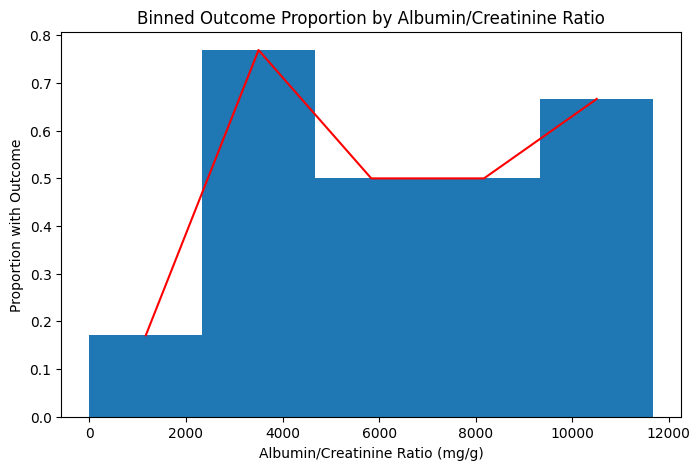

In [8]:
# Binned Proba for age
binned_var = 'P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g'
number_of_bins = 5
counts, bin_edges = np.histogram(X_train[binned_var], bins=number_of_bins)
bin_indices = np.digitize(X_train[binned_var], bins=bin_edges, right=True)

# Fix indices to be in range 0 to number_of_bins - 1
bin_indices = np.clip(bin_indices - 1, 0, number_of_bins - 1)

y_train_bin = y_train['IS_DIABETES']

bin_probas = []
for i in range(number_of_bins):
    bin_mask = (bin_indices == i)
    if np.sum(bin_mask) > 0:
        bin_probas.append(y_train_bin[bin_mask].mean())
    else:
        bin_probas.append(0)

bin_probas = np.array(bin_probas)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure(figsize=(8, 5))
plt.bar(bin_centers, bin_probas, width=np.diff(bin_edges))
plt.plot(bin_centers, bin_probas, color='red')
plt.xlabel('Albumin/Creatinine Ratio (mg/g)')
plt.ylabel('Proportion with Outcome')
plt.title('Binned Outcome Proportion by Albumin/Creatinine Ratio')

## Untuned GLM

### Statsmodel Version

In [9]:
model_glm_untuned = evaluate_glm_model(
    X_train_encoded,
    X_test_encoded,
    y_train,
    y_test
)


c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


Train ACC: 0.888, F1: 0.792, AUC: 0.776
Test  ACC: 0.877, F1: 0.765, AUC: 0.762



c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


CV ACC: 0.841 ± 0.030
CV F1: 0.673 ± 0.047
CV AUC: 0.700 ± 0.111
AIC = nan, BIC = nan


c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1056: RuntimeWarning: divide by zero encountered in log
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +
c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1056: RuntimeWarning: invalid value encountered in multiply
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +


                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7405
Model Family:                Binomial   Df Model:                          383
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                    nan
Date:                Fri, 05 Dec 2025   Deviance:                       80038.
Time:                        16:22:16   Pearson chi2:                 3.91e+18
No. Iterations:                    37   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

### Sklearn Version

Note: sklearn behave differently than statsmodel in how it approach the solution, which allows it to converge under extreme situation. However, to use sklearn lr to do statistical tuning is challenging since there's no built-in statistical scores like AIC for example.

In [4]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=10000, tol=1e-4, solver = 'newton-cg', penalty = None)
lr.fit(X_train_encoded, y_train_cat)
y_pred_test = lr.predict(X_test_encoded)
y_pred_train = lr.predict(X_train_encoded)
print(classification_report(y_test_cat, y_pred_test))


acc_train = accuracy_score(y_train_cat, y_pred_train)
acc_test  = accuracy_score(y_test_cat, y_pred_test)

f1_train = f1_score(y_train_cat, y_pred_train, average='macro')
f1_test  = f1_score(y_test_cat, y_pred_test, average='macro')

auc_train = roc_auc_score(y_train_cat, lr.predict_proba(X_train_encoded)[:, 1])
auc_test  = roc_auc_score(y_test_cat, lr.predict_proba(X_test_encoded)[:, 1])

print(f"Train Accuracy: {acc_train:.4f}, Test Accuracy: {acc_test:.4f}"
      f"\nTrain F1 Score: {f1_train:.4f}, Test F1 Score: {f1_test:.4f}"
      f"\nTrain AUC: {auc_train:.4f}, Test AUC: {auc_test:.4f}"
      ) 

# cross-validation
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'F1': make_scorer(f1_score, average='macro'),
    'AUC': make_scorer(roc_auc_score, needs_proba=True)
}
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(lr, X_train_encoded, y_train_cat, cv=kf, scoring=scoring)
print("Cross-Validation Results:")
for metric in scoring.keys():
    scores = cv_results[f'test_{metric}']
    print(f"{metric.capitalize()}: Mean = {scores.mean():.4f}, Std = {scores.std():.4f}")

              precision    recall  f1-score   support

         0.0       0.91      0.95      0.93      1642
         1.0       0.65      0.52      0.58       306

    accuracy                           0.88      1948
   macro avg       0.78      0.74      0.76      1948
weighted avg       0.87      0.88      0.88      1948

Train Accuracy: 0.8958, Test Accuracy: 0.8814
Train F1 Score: 0.7993, Test F1 Score: 0.7559
Train AUC: 0.9296, Test AUC: 0.8972


c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


Cross-Validation Results:
Accuracy: Mean = 0.8660, Std = 0.0039
F1: Mean = 0.7448, Std = 0.0055
Auc: Mean = 0.8872, Std = 0.0085


## ML Tuned GLM

### XGB Gain Tuned GLM

In [10]:
# gain feature importance
booster = xgb.get_booster()
score = booster.get_score(importance_type='gain')

importance_df = pd.DataFrame({
    'feature': list(score.keys()),
    'importance': list(score.values())
}).sort_values('importance', ascending=False)

top_n = 100
top_features = importance_df['feature'].head(top_n).tolist()

# fit
X_train_glm_top = X_train_encoded[top_features]
X_test_glm_top = X_test_encoded[top_features]

model_glm_top = evaluate_glm_model(
    X_train_glm_top,
    X_test_glm_top,
    y_train,
    y_test
)

Train ACC: 0.883, F1: 0.770, AUC: 0.911
Test  ACC: 0.891, F1: 0.770, AUC: 0.913

CV ACC: 0.874 ± 0.004
CV F1: 0.753 ± 0.006
CV AUC: 0.899 ± 0.008
AIC = 4382.147, BIC = 5085.154
                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7688
Model Family:                Binomial   Df Model:                          100
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2090.1
Date:                Fri, 05 Dec 2025   Deviance:                       4180.1
Time:                        16:22:21   Pearson chi2:                 7.27e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3177
Covariance Type:            nonrobust                                         
                                 

### XGB SHAP Tuned GLM

In [11]:
# read trees
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_train_encoded)
shap_vals = shap_values.values if hasattr(shap_values, "values") else shap_values
shap_feature_importance = np.abs(shap_vals).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': shap_feature_importance
}).sort_values('importance', ascending=False)

# top shap
top_n_shap = 100
top_features_shap = shap_importance_df['feature'].head(top_n_shap).tolist()

# fit
X_train_glm_shap = X_train_encoded[top_features_shap]
X_test_glm_shap = X_test_encoded[top_features_shap]

model_glm_shap = evaluate_glm_model(
    X_train_glm_shap,
    X_test_glm_shap,
    y_train,
    y_test,
    compute_vif=True
)

Train ACC: 0.883, F1: 0.770, AUC: 0.915
Test  ACC: 0.889, F1: 0.767, AUC: 0.913

CV ACC: 0.875 ± 0.004
CV F1: 0.757 ± 0.006
CV AUC: 0.902 ± 0.008
AIC = 4314.208, BIC = 5017.215
Max VIF: 641164.302
                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7688
Model Family:                Binomial   Df Model:                          100
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2056.1
Date:                Fri, 05 Dec 2025   Deviance:                       4112.2
Time:                        16:22:49   Pearson chi2:                 7.06e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3237
Covariance Type:            nonrobust                                         
             

## Statistical Tuning

#### Significance Backward Elimination

In [12]:
# apply backward elimination
X_train_be, be_model, removed = backward_elimination_classification(
    X_train_glm_shap, y_train, p_threshold=0.05
)

X_test_be = X_test_glm_shap[X_train_be.columns].astype(float)

model_be = evaluate_glm_model(
    X_train_be,
    X_test_be,
    y_train,
    y_test,
    compute_vif=True
)


Iteration 1
Features remaining: 100
Worst feature: P_BIOPRO__LBDSCHSI_Cholesterol_refrigerated_serum_mmol_L
Worst p-value: 0.9791
Train ACC: 0.8825, F1: 0.7697, AUC: 0.9145
Removing: P_BIOPRO__LBDSCHSI_Cholesterol_refrigerated_serum_mmol_L

Iteration 2
Features remaining: 99
Worst feature: P_ALB_CR__URXUMS_Albumin_urine_mg_L
Worst p-value: 0.9683
Train ACC: 0.8825, F1: 0.7697, AUC: 0.9145
Removing: P_ALB_CR__URXUMS_Albumin_urine_mg_L

Iteration 3
Features remaining: 98
Worst feature: P_ALB_CR__URXCRS_Creatinine_urine_umol_L
Worst p-value: 0.9351
Train ACC: 0.8824, F1: 0.7694, AUC: 0.9145
Removing: P_ALB_CR__URXCRS_Creatinine_urine_umol_L

Iteration 4
Features remaining: 97
Worst feature: P_MCQ__MCQ366A_2.0
Worst p-value: 0.9012
Train ACC: 0.8824, F1: 0.7692, AUC: 0.9145
Removing: P_MCQ__MCQ366A_2.0

Iteration 5
Features remaining: 96
Worst feature: P_BIOPRO__LBXSCK_Creatine_Phosphokinase_CPK_IU_L
Worst p-value: 0.8414
Train ACC: 0.8825, F1: 0.7694, AUC: 0.9145
Removing: P_BIOPRO__LBXS

#### Stepwise Selection

##### AIC Backward

In [13]:
X_step_aic_backward, model_aic_backward, history_aic_backward = stepwise_glm_backward(X_train_be, y_train, criterion="AIC")


Step:  AIC=4279.522
y ~ const + P_DEMO__RIDAGEYR_Age_in_years_at_screening + P_MCQ__MCQ300C_2.0 + P_LUX__LUXCAPM_Median_CAP_decibels_per_meter_dB_m + P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g + P_HUQ__HUQ051_times_receive_healthcare_over_past_year + P_BIOPRO__LBXSCLSI_Chloride_mmol_L + P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L + Pulse_median + P_PBCD__LBDBPBSI_Blood_lead_umol_L + P_MCQ__MCQ366D_2.0 + P_BPQ__BPQ020_Ever_told_you_had_high_blood_pressure_2.0 + P_HUQ__HUQ010_General_health_condition + P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_1.0 + P_BMX__BMXWAIST_Waist_Circumference_cm + P_TCHOL__LBDTCSI_Total_Cholesterol_mmol_L + P_BIOPRO__LBXSLDSI_Lactate_Dehydrogenase_LDH_IU_L + P_WHQ__WHQ150_Age_when_heaviest_weight + P_TST__LBXSHBG_SHBG_nmol_L + P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0 + P_LUX__LUXSMED_Median_stiffness_E_kilopascals_kPa + P_WHQ__WHD140_Self_reported_greatest_weight_pounds + P_PAQ__PAQ620_Moderate_work_activity_2.0 + P_CBC__LBXMPS

In [14]:
X_test_aic_bwd = X_test_be[X_step_aic_backward.columns].astype(float)

model_aic_backward_eval = evaluate_glm_model(
    X_step_aic_backward,
    X_test_aic_bwd,
    y_train,
    y_test,
    compute_vif=True
)

Train ACC: 0.880, F1: 0.763, AUC: 0.912
Test  ACC: 0.894, F1: 0.778, AUC: 0.912

CV ACC: 0.874 ± 0.004
CV F1: 0.753 ± 0.007
CV AUC: 0.905 ± 0.008
AIC = 4279.522, BIC = 4676.269
Max VIF: 6556.156
                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7732
Model Family:                Binomial   Df Model:                           56
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2082.8
Date:                Fri, 05 Dec 2025   Deviance:                       4165.5
Time:                        16:23:54   Pearson chi2:                 7.14e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3190
Covariance Type:            nonrobust                                         
               

##### BIC Backward

In [15]:
X_step_bic_backward, model_bic_backward, history_bic_backward = stepwise_glm_backward(X_train_be, y_train, criterion="BIC")


Step:  BIC=4676.269
y ~ const + P_DEMO__RIDAGEYR_Age_in_years_at_screening + P_MCQ__MCQ300C_2.0 + P_LUX__LUXCAPM_Median_CAP_decibels_per_meter_dB_m + P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g + P_HUQ__HUQ051_times_receive_healthcare_over_past_year + P_BIOPRO__LBXSCLSI_Chloride_mmol_L + P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L + Pulse_median + P_PBCD__LBDBPBSI_Blood_lead_umol_L + P_MCQ__MCQ366D_2.0 + P_BPQ__BPQ020_Ever_told_you_had_high_blood_pressure_2.0 + P_HUQ__HUQ010_General_health_condition + P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_1.0 + P_BMX__BMXWAIST_Waist_Circumference_cm + P_TCHOL__LBDTCSI_Total_Cholesterol_mmol_L + P_BIOPRO__LBXSLDSI_Lactate_Dehydrogenase_LDH_IU_L + P_WHQ__WHQ150_Age_when_heaviest_weight + P_TST__LBXSHBG_SHBG_nmol_L + P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0 + P_LUX__LUXSMED_Median_stiffness_E_kilopascals_kPa + P_WHQ__WHD140_Self_reported_greatest_weight_pounds + P_PAQ__PAQ620_Moderate_work_activity_2.0 + P_CBC__LBXMPS

In [16]:
X_test_bic_bwd = X_test_be[X_step_bic_backward.columns].astype(float)

model_bic_backward_eval = evaluate_glm_model(
    X_step_bic_backward,
    X_test_bic_bwd,
    y_train,
    y_test,
    compute_vif=True
)

Train ACC: 0.877, F1: 0.755, AUC: 0.907
Test  ACC: 0.899, F1: 0.789, AUC: 0.913

CV ACC: 0.876 ± 0.006
CV F1: 0.756 ± 0.011
CV AUC: 0.902 ± 0.007
AIC = 4345.355, BIC = 4616.813
Max VIF: 886.470
                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7750
Model Family:                Binomial   Df Model:                           38
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2133.7
Date:                Fri, 05 Dec 2025   Deviance:                       4267.4
Time:                        16:27:58   Pearson chi2:                 6.86e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3101
Covariance Type:            nonrobust                                         
                

##### AIC Forward

In [17]:
X_step_aic_forward, model_aic_forward, history_aic_forward = stepwise_glm_forward(X_train_be, y_train, criterion="AIC")


Step:  AIC=7160.176
y ~ 1 (intercept only)

Variable                                                                          Df      Sum of Sq            RSS        AIC
-----------------------------------------------------------------------------------------------------------------------------
+ P_DEMO__RIDAGEYR_Age_in_years_at_screening                                       1        990.705       6167.471   6171.471
+ P_LUX__LUXCAPM_Median_CAP_decibels_per_meter_dB_m                                1        763.581       6394.596   6398.596
+ P_BPQ__BPQ020_Ever_told_you_had_high_blood_pressure_2.0                          1        756.069       6402.108   6406.108
+ P_BMX__BMXWAIST_Waist_Circumference_cm                                           1        666.701       6491.475   6495.475
+ P_WHQ__WHQ150_Age_when_heaviest_weight                                           1        608.481       6549.696   6553.696
+ P_MCQ__MCQ366D_2.0                                                     

In [18]:
X_test_aic_fwd = X_test_be[X_step_aic_forward.columns].astype(float)

model_aic_forward_eval = evaluate_glm_model(
    X_step_aic_forward,
    X_test_aic_fwd,
    y_train,
    y_test,
    compute_vif=True
)

Train ACC: 0.880, F1: 0.763, AUC: 0.912
Test  ACC: 0.894, F1: 0.778, AUC: 0.912

CV ACC: 0.874 ± 0.004
CV F1: 0.753 ± 0.007
CV AUC: 0.905 ± 0.008
AIC = 4279.522, BIC = 4676.269
Max VIF: 6556.156
                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7732
Model Family:                Binomial   Df Model:                           56
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2082.8
Date:                Fri, 05 Dec 2025   Deviance:                       4165.5
Time:                        16:30:44   Pearson chi2:                 7.14e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3190
Covariance Type:            nonrobust                                         
               

##### BIC Forward

In [19]:
X_step_bic_forward, model_bic_forward, history_bic_forward = stepwise_glm_forward(X_train_be, y_train, criterion="BIC")


Step:  BIC=7167.137
y ~ 1 (intercept only)

Variable                                                                          Df      Sum of Sq            RSS        BIC
-----------------------------------------------------------------------------------------------------------------------------
+ P_DEMO__RIDAGEYR_Age_in_years_at_screening                                       1        990.705       6167.471   6185.392
+ P_LUX__LUXCAPM_Median_CAP_decibels_per_meter_dB_m                                1        763.581       6394.596   6412.516
+ P_BPQ__BPQ020_Ever_told_you_had_high_blood_pressure_2.0                          1        756.069       6402.108   6420.028
+ P_BMX__BMXWAIST_Waist_Circumference_cm                                           1        666.701       6491.475   6509.396
+ P_WHQ__WHQ150_Age_when_heaviest_weight                                           1        608.481       6549.696   6567.617
+ P_MCQ__MCQ366D_2.0                                                     

In [20]:
X_test_bic_fwd = X_test_be[X_step_bic_forward.columns].astype(float)

model_bic_forward_eval = evaluate_glm_model(
    X_step_bic_forward,
    X_test_bic_fwd,
    y_train,
    y_test,
    compute_vif=True
)

Train ACC: 0.875, F1: 0.752, AUC: 0.904
Test  ACC: 0.897, F1: 0.782, AUC: 0.904

CV ACC: 0.874 ± 0.003
CV F1: 0.749 ± 0.006
CV AUC: 0.899 ± 0.005
AIC = 4400.375, BIC = 4623.110
Max VIF: 405.805
                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7757
Model Family:                Binomial   Df Model:                           31
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2168.2
Date:                Fri, 05 Dec 2025   Deviance:                       4336.4
Time:                        16:32:21   Pearson chi2:                 7.37e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3039
Covariance Type:            nonrobust                                         
                

#### VIF Drops

##### VIF Auto-tune

In [21]:
# apply VIF with thresholds
numeric_cols = X_step_bic_forward.select_dtypes(include=['number']).columns.tolist()
X_vif = X_step_bic_forward[numeric_cols].dropna()

vif_thresholds = [100, 60, 40, 30, 20, 10, 5]
threshold_results = {}
current_threshold_idx = 0

# Initialize
vif_summary = pd.DataFrame({'feature': X_vif.columns})

iteration = 0
print(f"Starting with {len(X_vif.columns)} features\n")

while current_threshold_idx < len(vif_thresholds):
    iteration += 1
    
    # Calculate VIF
    vif_values = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    max_vif = max(vif_values)
    
    vif = pd.DataFrame({
        'feature': X_vif.columns,
        f'VIF_iter{iteration}': vif_values
    })
    
    vif_summary = vif_summary.merge(vif, on='feature', how='left')
    
    current_threshold = vif_thresholds[current_threshold_idx]
    
    # Check if we've dropped below current threshold
    if max_vif < current_threshold:
        print(f"\n{'='*60}")
        print(f"VIF < {current_threshold} REACHED")
        print(f"{'='*60}")
        
        # store results for this threshold
        final_features = X_vif.columns.tolist()
        threshold_results[current_threshold] = {
            'features': final_features,
            'n_features': len(final_features)
        }
        
        print(f"Features remaining: {len(final_features)}")
        print(f"Features removed: {len(numeric_cols) - len(final_features)}")
        
        # next threshold
        current_threshold_idx += 1
        
        # If we've reached the last threshold, break
        if current_threshold_idx >= len(vif_thresholds):
            break
        
        continue
    
    # Find max VIF and drop
    max_idx = vif_values.index(max_vif)
    drop_col = X_vif.columns[max_idx]
    
    print(f"[{iteration}] Drop {drop_col}: VIF={max_vif:.1f}")
    X_vif = X_vif.drop(columns=drop_col)

# Summary comparison
print("\n" + "="*60)
print("SUMMARY: Feature Count by VIF Threshold")
print("="*60)
print(f"{'Threshold':<12} {'Features':<12} {'Removed':<12} {'% Remaining':<12}")
print("-"*60)

for threshold in vif_thresholds:
    if threshold in threshold_results:
        n_features = threshold_results[threshold]['n_features']
        n_removed = len(numeric_cols) - n_features
        pct_remaining = (n_features / len(numeric_cols)) * 100
        print(f"VIF < {threshold:<6} {n_features:<12} {n_removed:<12} {pct_remaining:.1f}%")

Starting with 31 features

[1] Drop P_BIOPRO__LBXSCLSI_Chloride_mmol_L: VIF=405.8
[2] Drop P_BMX__BMXWAIST_Waist_Circumference_cm: VIF=272.8
[3] Drop P_BMX__BMXHIP_Hip_Circumference_cm: VIF=136.9
[4] Drop P_BMX__BMXLEG_Upper_Leg_Length_cm: VIF=122.1
[5] Drop BP_sys_median: VIF=116.7

VIF < 100 REACHED
Features remaining: 26
Features removed: 5
[7] Drop P_BIOPRO__LBXSC3SI_Bicarbonate_mmol_L: VIF=83.0

VIF < 60 REACHED
Features remaining: 25
Features removed: 6
[9] Drop P_CBC__LBXMPSI_Mean_platelet_volume_fL: VIF=58.5
[10] Drop BP_dia_median: VIF=51.0

VIF < 40 REACHED
Features remaining: 23
Features removed: 8
[12] Drop Pulse_median: VIF=37.8

VIF < 30 REACHED
Features remaining: 22
Features removed: 9
[14] Drop P_LUX__LUXCAPM_Median_CAP_decibels_per_meter_dB_m: VIF=27.4
[15] Drop P_TCHOL__LBDTCSI_Total_Cholesterol_mmol_L: VIF=26.4
[16] Drop P_BIOPRO__LBXSLDSI_Lactate_Dehydrogenase_LDH_IU_L: VIF=21.9

VIF < 20 REACHED
Features remaining: 19
Features removed: 12
[18] Drop P_HDL__LBDHDDSI

In [22]:
# choose VIF cutoff
n_VIF_thresh = 20
print(f"\nEvaluating GLM with VIF < {n_VIF_thresh} features\n")

# get selected feature list
vif_features = threshold_results[n_VIF_thresh]['features']

# subset TRAIN and TEST using those features
X_train_vif = X_train_be[vif_features]
X_test_vif  = X_test_be[vif_features]

model_glm_vif = evaluate_glm_model(
    X_train_vif,
    X_test_vif,
    y_train,
    y_test,
    compute_vif=True
)


Evaluating GLM with VIF < 20 features

Train ACC: 0.858, F1: 0.703, AUC: 0.877
Test  ACC: 0.878, F1: 0.724, AUC: 0.884

CV ACC: 0.855 ± 0.007
CV F1: 0.697 ± 0.009
CV AUC: 0.875 ± 0.005
AIC = 4865.169, BIC = 5004.378
Max VIF: 14.306
                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7769
Model Family:                Binomial   Df Model:                           19
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2412.6
Date:                Fri, 05 Dec 2025   Deviance:                       4825.2
Time:                        16:32:37   Pearson chi2:                 9.19e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2588
Covariance Type:            nonrobust                   

##### VIF-LRT Manual Tune

In [23]:
drop_list = []
evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                   feature        VIF  importance
4            P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L  14.306209   45.628678
7                         P_CBC__LBXMOPCT_Monocyte_percent  13.818670   20.591353
12      P_WHQ__WHD140_Self_reported_greatest_weight_pounds  13.794995   98.190865
13                     P_FETIB__LBDUIBSI_UIBC_Serum_umol_L  13.608782   32.777603
2                   P_HUQ__HUQ010_General_health_condition   8.771954   70.996213
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening   8.598620  782.410815
3                                       P_MCQ__MCQ366D_2.0   3.836414   66.935321
11    P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L   3.298090   24.494359
17                              P_TST__LBXSHBG_SHBG_nmol_L   2.976463   28.086108
5     P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0   2.867176   10.002507
1                                       P_MCQ__MCQ300C_2.0   2.628133  178.764874
16              

Drops  : P_DEMO__RIDEXMON_Six_month_time_period_2.0  
Reason : High p-values

In [24]:
drop_list = ['P_DEMO__RIDEXMON_Six_month_time_period_2.0']
evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                   feature        VIF  importance
4            P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L  14.305274   46.568119
7                         P_CBC__LBXMOPCT_Monocyte_percent  13.799754   20.338481
12      P_WHQ__WHD140_Self_reported_greatest_weight_pounds  13.741514   98.326359
13                     P_FETIB__LBDUIBSI_UIBC_Serum_umol_L  13.588261   32.853997
2                   P_HUQ__HUQ010_General_health_condition   8.761568   71.646905
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening   8.598617  781.640420
3                                       P_MCQ__MCQ366D_2.0   3.834816   67.279048
11    P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L   3.296443   24.487297
17                              P_TST__LBXSHBG_SHBG_nmol_L   2.971006   27.453743
5     P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0   2.819557    9.276610
1                                       P_MCQ__MCQ300C_2.0   2.624260  178.751971
16              

Drops  : P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L  
Reason : High VIF. Correlation with Triglycerides and SHBG is high, but both have much lower VIF, and the LRT of correlated variables are relatively comparable with HDL Cholesterol.

In [25]:
drop_list=[
        'P_DEMO__RIDEXMON_Six_month_time_period_2.0',
        'P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L',
    ]

evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                   feature        VIF  importance
11      P_WHQ__WHD140_Self_reported_greatest_weight_pounds  13.674417  126.215942
6                         P_CBC__LBXMOPCT_Monocyte_percent  13.248217   17.710419
12                     P_FETIB__LBDUIBSI_UIBC_Serum_umol_L  12.424382   29.725794
2                   P_HUQ__HUQ010_General_health_condition   8.738395   81.309324
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening   8.146102  749.252068
3                                       P_MCQ__MCQ366D_2.0   3.639192   68.337571
10    P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L   3.060187   61.508511
4     P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0   2.815872    7.976430
16                              P_TST__LBXSHBG_SHBG_nmol_L   2.735987   50.487347
15                P_PAQ__PAQ620_Moderate_work_activity_2.0   2.607107   14.615903
1                                       P_MCQ__MCQ300C_2.0   2.588397  180.932121
9               

Drops  : P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_4.0  
Reason : P-values raises significantly after dropping HDL Cholesterol

In [26]:
drop_list=[
        'P_DEMO__RIDEXMON_Six_month_time_period_2.0',
        'P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L',
        'P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_4.0',
    ]

evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                   feature        VIF  importance
11      P_WHQ__WHD140_Self_reported_greatest_weight_pounds  13.252906  130.502921
6                         P_CBC__LBXMOPCT_Monocyte_percent  12.953881   16.689662
12                     P_FETIB__LBDUIBSI_UIBC_Serum_umol_L  12.403395   29.825100
2                   P_HUQ__HUQ010_General_health_condition   8.738342   80.977610
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening   8.042864  762.236737
3                                       P_MCQ__MCQ366D_2.0   3.633108   68.112147
10    P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L   3.006360   59.386509
15                              P_TST__LBXSHBG_SHBG_nmol_L   2.732146   50.656842
14                P_PAQ__PAQ620_Moderate_work_activity_2.0   2.603437   14.993248
1                                       P_MCQ__MCQ300C_2.0   2.588307  181.574277
9                       P_PBCD__LBDBPBSI_Blood_lead_umol_L   2.255102   22.005313
4     P_DEMO__RI

Drops  : P_WHQ__WHD140_Self_reported_greatest_weight_pounds  
Reason : It has high importance. However, it is too far from the target of VIF < 5 and the 3 next variables with high correlation to it have lower VIF and greater importance in totals.

In [27]:
drop_list=[
        'P_DEMO__RIDEXMON_Six_month_time_period_2.0',
        'P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L',
        'P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_4.0',
        'P_WHQ__WHD140_Self_reported_greatest_weight_pounds',
    ]

evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                   feature        VIF  importance
6                         P_CBC__LBXMOPCT_Monocyte_percent  11.901128   15.180105
11                     P_FETIB__LBDUIBSI_UIBC_Serum_umol_L  10.989888   25.499771
2                   P_HUQ__HUQ010_General_health_condition   7.836705  116.392110
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening   7.771519  720.415303
3                                       P_MCQ__MCQ366D_2.0   3.626471  121.907509
10    P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L   2.949721   60.199538
14                              P_TST__LBXSHBG_SHBG_nmol_L   2.693187   78.639137
13                P_PAQ__PAQ620_Moderate_work_activity_2.0   2.603260   10.427308
1                                       P_MCQ__MCQ300C_2.0   2.587309  196.607279
9                       P_PBCD__LBDBPBSI_Blood_lead_umol_L   2.254192   27.304405
4     P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0   1.894764   21.221636
7   P_FASTQX__PH

Drops  : P_DEMO__DMDBORN4_Country_of_birth_2.0  
Reason : Inflated p-value after dropping the greatest weight

In [28]:
drop_list=[
        'P_DEMO__RIDEXMON_Six_month_time_period_2.0',
        'P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L',
        'P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_4.0',
        'P_WHQ__WHD140_Self_reported_greatest_weight_pounds',
        'P_DEMO__DMDBORN4_Country_of_birth_2.0',
    ]

evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                   feature        VIF  importance
6                         P_CBC__LBXMOPCT_Monocyte_percent  11.835967   15.360156
11                     P_FETIB__LBDUIBSI_UIBC_Serum_umol_L  10.933869   25.537220
2                   P_HUQ__HUQ010_General_health_condition   7.831367  116.407069
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening   7.588145  726.190487
3                                       P_MCQ__MCQ366D_2.0   3.619829  121.943619
10    P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L   2.872458   61.730394
13                              P_TST__LBXSHBG_SHBG_nmol_L   2.692168   78.902184
12                P_PAQ__PAQ620_Moderate_work_activity_2.0   2.587293   10.502618
1                                       P_MCQ__MCQ300C_2.0   2.571427  198.153542
9                       P_PBCD__LBDBPBSI_Blood_lead_umol_L   2.243963   27.308227
7   P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_1.0   1.756178   37.127500
4     P_DEMO__RI

Drops  : P_CBC__LBXMOPCT_Monocyte_percent  
Reason : High VIF and low importance

In [29]:
drop_list=[
        'P_DEMO__RIDEXMON_Six_month_time_period_2.0',
        'P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L',
        'P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_4.0',
        'P_WHQ__WHD140_Self_reported_greatest_weight_pounds',
        'P_DEMO__DMDBORN4_Country_of_birth_2.0',
        'P_CBC__LBXMOPCT_Monocyte_percent',
    ]

evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                   feature       VIF  importance
10                     P_FETIB__LBDUIBSI_UIBC_Serum_umol_L  9.826730   27.921086
2                   P_HUQ__HUQ010_General_health_condition  7.489994  118.147044
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening  6.775699  710.865344
3                                       P_MCQ__MCQ366D_2.0  3.400681  122.017434
9     P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L  2.872374   65.568055
12                              P_TST__LBXSHBG_SHBG_nmol_L  2.692127   79.230248
11                P_PAQ__PAQ620_Moderate_work_activity_2.0  2.564996   10.998828
1                                       P_MCQ__MCQ300C_2.0  2.492612  201.356685
8                       P_PBCD__LBDBPBSI_Blood_lead_umol_L  2.240686   29.086036
6   P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_1.0  1.754604   36.677855
4     P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0  1.626749   26.694554
7   P_FASTQX__PHDSESN_Sessio

Drops  : P_FETIB__LBDUIBSI_UIBC_Serum_umol_L  
Reason : High VIF and the next variable with moderate correlation (age in years) is significantly much more important.

In [30]:
drop_list=[
        'P_DEMO__RIDEXMON_Six_month_time_period_2.0',
        'P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L',
        'P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_4.0',
        'P_WHQ__WHD140_Self_reported_greatest_weight_pounds',
        'P_DEMO__DMDBORN4_Country_of_birth_2.0',
        'P_CBC__LBXMOPCT_Monocyte_percent',
        'P_FETIB__LBDUIBSI_UIBC_Serum_umol_L',
    ]

evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                   feature       VIF  importance
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening  6.726064  683.028564
2                   P_HUQ__HUQ010_General_health_condition  6.105944  122.794675
3                                       P_MCQ__MCQ366D_2.0  3.166729  129.652225
9     P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L  2.789170   67.999697
11                              P_TST__LBXSHBG_SHBG_nmol_L  2.552265   74.191057
10                P_PAQ__PAQ620_Moderate_work_activity_2.0  2.446060   11.779142
1                                       P_MCQ__MCQ300C_2.0  2.398355  205.901001
8                       P_PBCD__LBDBPBSI_Blood_lead_umol_L  2.238515   32.788700
6   P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_1.0  1.722206   32.770336
4     P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0  1.624840   26.473913
7   P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_2.0  1.298533   28.160713
5           P_ALB_CR__URDACT

Drops  : P_PBCD__LBDBPBSI_Blood_lead_umol_L  
Reason : Age years VIF is 6.72 but the blood lead have 0.33 correlation against it with much lower importance.

In [31]:
drop_list=[
        'P_DEMO__RIDEXMON_Six_month_time_period_2.0',
        'P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L',
        'P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_4.0',
        'P_WHQ__WHD140_Self_reported_greatest_weight_pounds',
        'P_DEMO__DMDBORN4_Country_of_birth_2.0',
        'P_CBC__LBXMOPCT_Monocyte_percent',
        'P_FETIB__LBDUIBSI_UIBC_Serum_umol_L',
        'P_PBCD__LBDBPBSI_Blood_lead_umol_L',
    ]

evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                   feature       VIF  importance
2                   P_HUQ__HUQ010_General_health_condition  6.096496  118.756966
0               P_DEMO__RIDAGEYR_Age_in_years_at_screening  5.878182  652.019151
3                                       P_MCQ__MCQ366D_2.0  3.136665  143.835060
8     P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L  2.787228   65.875024
10                              P_TST__LBXSHBG_SHBG_nmol_L  2.552262   80.661436
9                 P_PAQ__PAQ620_Moderate_work_activity_2.0  2.443853   12.812353
1                                       P_MCQ__MCQ300C_2.0  2.396119  211.487111
6   P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_1.0  1.721413   30.127460
4     P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0  1.616702   22.001948
7   P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_2.0  1.298509   28.796989
5           P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g  1.032574   30.228256

Max VIF: 6.1


Correlations

Drops  : P_HUQ__HUQ010_General_health_condition  
Reason : High VIF and the correlated variables with correlation > 0.2 have much importance and lower VIF

In [32]:
drop_list=[
        'P_DEMO__RIDEXMON_Six_month_time_period_2.0',
        'P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L',
        'P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_4.0',
        'P_WHQ__WHD140_Self_reported_greatest_weight_pounds',
        'P_DEMO__DMDBORN4_Country_of_birth_2.0',
        'P_CBC__LBXMOPCT_Monocyte_percent',
        'P_FETIB__LBDUIBSI_UIBC_Serum_umol_L',
        'P_PBCD__LBDBPBSI_Blood_lead_umol_L',
        'P_HUQ__HUQ010_General_health_condition',
    ]

evaluate_VIF_LRT(drop_list, X_train_vif, X_test_vif, y_train, y_test)

                                                  feature       VIF  importance
0              P_DEMO__RIDAGEYR_Age_in_years_at_screening  4.170569  720.108240
2                                      P_MCQ__MCQ366D_2.0  3.092546  200.998130
7    P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L  2.639580   75.015214
9                              P_TST__LBXSHBG_SHBG_nmol_L  2.511217   74.221911
8                P_PAQ__PAQ620_Moderate_work_activity_2.0  2.389521   13.727578
1                                      P_MCQ__MCQ300C_2.0  2.375032  239.183565
5  P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_1.0  1.714978   34.078855
3    P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0  1.611601   34.381880
6  P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_2.0  1.291325   32.678020
4          P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g  1.028520   41.449290

Max VIF: 4.2


Correlations with P_DEMO__RIDAGEYR_Age_in_years_at_screening (importance: 720.11.):

                   

## Final Model

After dropping the set of variables below, the maximum VIF is now below 5. 

```
drop_list=[
        'P_DEMO__RIDEXMON_Six_month_time_period_2.0',
        'P_HDL__LBDHDDSI_Direct_HDL_Cholesterol_mmol_L',
        'P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_4.0',
        'P_WHQ__WHD140_Self_reported_greatest_weight_pounds',
        'P_DEMO__DMDBORN4_Country_of_birth_2.0',
        'P_CBC__LBXMOPCT_Monocyte_percent',
        'P_FETIB__LBDUIBSI_UIBC_Serum_umol_L',
        'P_PBCD__LBDBPBSI_Blood_lead_umol_L',
        'P_HUQ__HUQ010_General_health_condition',
    ]
```

In [33]:
X_train_final = X_train_vif.drop(columns=drop_list)
X_test_final  = X_test_vif.drop(columns=drop_list)

model_final = evaluate_glm_model(
    X_train_final,
    X_test_final,
    y_train,
    y_test
)

Train ACC: 0.851, F1: 0.670, AUC: 0.854
Test  ACC: 0.860, F1: 0.680, AUC: 0.861

CV ACC: 0.849 ± 0.008
CV F1: 0.667 ± 0.018
CV AUC: 0.853 ± 0.007
AIC = 5222.774, BIC = 5299.339
                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7778
Model Family:                Binomial   Df Model:                           10
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2600.4
Date:                Fri, 05 Dec 2025   Deviance:                       5200.8
Time:                        16:32:52   Pearson chi2:                 1.20e+04
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2222
Covariance Type:            nonrobust                                         
                                 

## Experimental SHAP Interaction

Below is the interaction on the most important variable that we found in SHAP. Please refer to shap_interaction_analysis.xlsx. Overall, the interaction is too weak and don't provide any meaningful value.

| Feature 1 | Feature 2 | Correlation |
|-----------|-----------|-------------|
| Age | ACR | 0.029 |
| ACR | Low Fat/Calories Diet | 0.028 |
| Age | SHBG | 0.017 |
| SHBG | Tested at morning | 0.012 |
| Age | Low Fat/Calories Diet | 0.011 |
| Age | NH White | 0.010 |
| Age | No Diabetic Family | 0.009 |
| Age | Triglycerides | 0.008 |
| Tested at morning | Sedentary jobs | 0.007 |
| SHBG | Sedentary jobs | 0.002 |
| ACR | SHBG | 0.001 |

### Interaction Against Final Model

In [34]:
X_train_final_interaction_1 = X_train_final.copy()
X_test_final_interaction_1 = X_test_final.copy()

interactions = [
    ('P_DEMO__RIDAGEYR_Age_in_years_at_screening', 'P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g'),
    ('P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g', 'P_MCQ__MCQ366D_2.0'),
    ('P_DEMO__RIDAGEYR_Age_in_years_at_screening', 'P_TST__LBXSHBG_SHBG_nmol_L'),
    ('P_TST__LBXSHBG_SHBG_nmol_L', 'P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_1.0'),
    ('P_DEMO__RIDAGEYR_Age_in_years_at_screening', 'P_MCQ__MCQ366D_2.0'),
    ('P_DEMO__RIDAGEYR_Age_in_years_at_screening', 'P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0'),
    ('P_DEMO__RIDAGEYR_Age_in_years_at_screening', 'P_MCQ__MCQ300C_2.0'),
    ('P_DEMO__RIDAGEYR_Age_in_years_at_screening', 'P_BIOPRO__LBDSTRSI_Triglycerides_refrig_serum_mmol_L'),
    ('P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_1.0', 'P_PAQ__PAQ620_Moderate_work_activity_2.0'),
    ('P_TST__LBXSHBG_SHBG_nmol_L', 'P_PAQ__PAQ620_Moderate_work_activity_2.0'),
    ('P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g', 'P_PAQ__PAQ620_Moderate_work_activity_2.0'),
]

for feat1, feat2 in interactions:
    interaction_name = f'{feat1}_x_{feat2}'
    X_train_final_interaction_1[interaction_name] = X_train_final[feat1] * X_train_final[feat2]
    X_test_final_interaction_1[interaction_name] = X_test_final[feat1] * X_test_final[feat2]

model_final_interaction = evaluate_glm_model(
    X_train_final_interaction_1,
    X_test_final_interaction_1,
    y_train,
    y_test
)

Train ACC: 0.851, F1: 0.670, AUC: 0.857
Test  ACC: 0.861, F1: 0.686, AUC: 0.861

CV ACC: 0.849 ± 0.007
CV F1: 0.666 ± 0.016
CV AUC: 0.854 ± 0.008
AIC = 5184.508, BIC = 5337.639
                 Generalized Linear Model Regression Results                  
Dep. Variable:            IS_DIABETES   No. Observations:                 7789
Model:                            GLM   Df Residuals:                     7767
Model Family:                Binomial   Df Model:                           21
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2570.3
Date:                Fri, 05 Dec 2025   Deviance:                       5140.5
Time:                        16:32:53   Pearson chi2:                 7.67e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2282
Covariance Type:            nonrobust                                         
                                 

### Backward Significance Elimination

In [35]:
X_train_final_interaction_significant, interaction_model_significant, removed_interaction = backward_elimination_classification(
    X_train_final_interaction_1, y_train, p_threshold=0.05
)

removed_cols = [col for col, pval in removed_interaction]

X_test_final_interaction_significant = X_test_final_interaction_1.drop(columns=removed_cols)

model_final_interaction_significant = evaluate_glm_model(
    X_train_final_interaction_significant,
    X_test_final_interaction_significant,
    y_train,
    y_test
)


Iteration 1
Features remaining: 21
Worst feature: P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g_x_P_MCQ__MCQ366D_2.0
Worst p-value: 0.8469
Train ACC: 0.8509, F1: 0.6702, AUC: 0.8565
Removing: P_ALB_CR__URDACT_Albumin_creatinine_ratio_mg_g_x_P_MCQ__MCQ366D_2.0

Iteration 2
Features remaining: 20
Worst feature: P_DEMO__RIDAGEYR_Age_in_years_at_screening_x_P_MCQ__MCQ300C_2.0
Worst p-value: 0.7814
Train ACC: 0.8511, F1: 0.6704, AUC: 0.8565
Removing: P_DEMO__RIDAGEYR_Age_in_years_at_screening_x_P_MCQ__MCQ300C_2.0

Iteration 3
Features remaining: 19
Worst feature: P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0
Worst p-value: 0.7187
Train ACC: 0.8512, F1: 0.6702, AUC: 0.8565
Removing: P_DEMO__RIDRETH3_Race_Hispanic_origin_w_NH_Asian_3.0

Iteration 4
Features remaining: 18
Worst feature: P_FASTQX__PHDSESN_Session_in_which_SP_was_examined_1.0_x_P_PAQ__PAQ620_Moderate_work_activity_2.0
Worst p-value: 0.6322
Train ACC: 0.8517, F1: 0.6714, AUC: 0.8565
Removing: P_FASTQX__PHDSESN_Session_in